In [9]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

warnings.filterwarnings("ignore", category=UserWarning)

RAW_FILE = Path("meridian_daily_sales_raw.csv")
CLEAN_FILE = Path("meridian_daily_sales_cleaned.csv")
PLOT_DIR = Path("meridian_plots")
PLOT_DIR.mkdir(exist_ok=True)

# helpers
def print_title(q, text):
    print("\n" + "=" * 90)
    print(f"Q{q}. {text}")
    print("=" * 90)

def parse_money(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if not s or s.lower() in {"na", "n/a", "null", "none", "nan"}:
        return np.nan
    # Remove currency words/symbols and thousands separators.
    s = re.sub(r"(?i)inr|usd|rs\.?", "", s)
    s = s.replace("$", "").replace(",", "").strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

def parse_mixed_date(value):
    if pd.isna(value):
        return pd.NaT
    s = str(value).strip()
    if not s:
        return pd.NaT

    # Explicitly handle slash-separated ambiguous dates as DD/MM/YYYY.
    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{4}", s):
        return pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")

    # Try common non-ambiguous/export formats.
    formats = [
        "%Y-%m-%d", "%Y/%m/%d",
        "%d-%m-%Y", "%d.%m.%Y",
        "%m-%d-%Y", "%m/%d/%Y",
        "%d %b %Y", "%d %B %Y",
        "%b %d, %Y", "%B %d, %Y",
    ]
    for fmt in formats:
        dt = pd.to_datetime(s, format=fmt, errors="coerce")
        if not pd.isna(dt):
            return dt
    return pd.to_datetime(s, errors="coerce")

def clean_bool(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {"y", "yes", "1", "true", "t"}:
        return True
    if s in {"n", "no", "0", "false", "f"}:
        return False
    return np.nan

In [10]:
# Q1 - Load and inspect
print_title(1, "Load the file. Print shape and dtypes.")
if not RAW_FILE.exists():
    raise FileNotFoundError(
        f"{RAW_FILE} not found. Put the raw CSV in the same folder as this script."
    )
df = pd.read_csv(RAW_FILE)
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nInterpretation: The raw export is loaded without hand-editing it.")



Q1. Load the file. Print shape and dtypes.
Shape: (1627, 10)

Dtypes:
 store_id             object
store_name           object
region               object
date                 object
transactions          int64
revenue              object
avg_basket_value    float64
discount_pct         object
footfall              int64
stockout_flag        object
dtype: object

Interpretation: The raw export is loaded without hand-editing it.


In [11]:
# Q2 - Standardize text fields

print_title(2, "Standardize store_id, store_name, region.")
for col in ["store_id", "store_name", "region"]:
    df[col] = df[col].astype("string").str.strip()

df["store_id"] = df["store_id"].str.upper()
df["store_name"] = df["store_name"].str.upper()
df["region"] = df["region"].str.upper()

print(df[["store_id", "store_name", "region"]].head())
print("Interpretation: Whitespace and case variations are normalized so equivalent stores/regions match.")


Q2. Standardize store_id, store_name, region.
  store_id       store_name region
0    ST-10  MAGNOLIA SQUARE  SOUTH
1    ST-13   HIGHLAND COURT   WEST
2    ST-16  REDWOOD STATION   WEST
3    ST-14    GOLDEN VALLEY   WEST
4    ST-04  SILVERLINE MALL  NORTH
Interpretation: Whitespace and case variations are normalized so equivalent stores/regions match.


In [12]:
# Q3 - Parse dates

print_title(3, "Parse date into a real date column.")
print(
    "Assumption: genuinely ambiguous slash dates such as 03/04/2026 are interpreted "
    "as DD/MM/YYYY (Indian/local convention), explicitly rather than silently guessing."
)
df["date"] = df["date"].apply(parse_mixed_date)
print("Unparsed dates:", int(df["date"].isna().sum()))
print("Date dtype:", df["date"].dtype)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Interpretation: The mixed date field is converted to a real datetime column.")



Q3. Parse date into a real date column.
Assumption: genuinely ambiguous slash dates such as 03/04/2026 are interpreted as DD/MM/YYYY (Indian/local convention), explicitly rather than silently guessing.
Unparsed dates: 142
Date dtype: datetime64[ns]
Date range: 2026-01-03 00:00:00 to 2026-12-05 00:00:00
Interpretation: The mixed date field is converted to a real datetime column.


In [13]:
# Q4 - Missing values and revenue

print_title(4, "Report missing values and clean revenue.")
print("Missing values before cleaning:\n", df.isna().sum())
df["revenue"] = df["revenue"].apply(parse_money)
print("\nRevenue dtype after cleaning:", df["revenue"].dtype)
print("Revenue missing after currency parsing:", int(df["revenue"].isna().sum()))
print(
    "Interpretation: Blank revenue remains missing rather than being fabricated; "
    "currency text and separators are converted to numeric USD."
)


Q4. Report missing values and clean revenue.
Missing values before cleaning:
 store_id              0
store_name            0
region                0
date                142
transactions          0
revenue              53
avg_basket_value      0
discount_pct          0
footfall              0
stockout_flag         0
dtype: int64

Revenue dtype after cleaning: float64
Revenue missing after currency parsing: 53
Interpretation: Blank revenue remains missing rather than being fabricated; currency text and separators are converted to numeric USD.


In [14]:
# Q5 - stockout flag

print_title(5, "Standardize stockout_flag to boolean.")
raw_stockout = df["stockout_flag"].value_counts(dropna=False)
df["stockout_flag"] = df["stockout_flag"].apply(clean_bool).astype("boolean")
print("Raw stockout values:\n", raw_stockout)
print("\nCleaned values:", df["stockout_flag"].value_counts(dropna=False).to_dict())
print("Interpretation: Y/1/yes/TRUE map to True and N/0/no/FALSE map to False.")



Q5. Standardize stockout_flag to boolean.
Raw stockout values:
 stockout_flag
N        636
0        249
no       176
Y        167
yes      163
TRUE      87
1         78
FALSE     71
Name: count, dtype: int64

Cleaned values: {False: 1132, True: 495}
Interpretation: Y/1/yes/TRUE map to True and N/0/no/FALSE map to False.


In [15]:
# Q6 - Duplicate ST-11 week

print_title(6, "Detect and remove the duplicate ST-11 week.")
before = len(df)

# The duplicate block differs only in store_name casing/whitespace in the raw data.
# We use normalized identifying fields rather than the original store_name spelling.
key_cols = [
    "store_id", "date", "transactions", "revenue", "avg_basket_value",
    "discount_pct", "footfall", "stockout_flag"
]
normalized_dup_mask = df.duplicated(subset=key_cols, keep="first")
duplicate_rows = df.loc[normalized_dup_mask].copy()

# If the raw export has exact duplicate business records with only store-name
# casing differences, store_id + the remaining business fields identify them.
df = df.loc[~normalized_dup_mask].copy()

after = len(df)
print("Rows before:", before)
print("Duplicate rows detected:", len(duplicate_rows))
print("Rows after:", after)
if not duplicate_rows.empty:
    print("Detected duplicate examples:\n", duplicate_rows.head(10))
print(
    "Interpretation: Duplicate business records are removed after normalizing the "
    "identity fields; the before/after counts document the change."
)


Q6. Detect and remove the duplicate ST-11 week.
Rows before: 1627
Duplicate rows detected: 7
Rows after: 1620
Detected duplicate examples:
      store_id    store_name region       date  transactions   revenue  \
662     ST-11  WILLOW CREEK  SOUTH 2026-03-10            96  12054.82   
726     ST-11  WILLOW CREEK  SOUTH 2026-03-08            68   5416.18   
973     ST-11  WILLOW CREEK  SOUTH 2026-03-09            60   2836.43   
1180    ST-11  WILLOW CREEK  SOUTH 2026-03-12            47   4665.13   
1251    ST-11  WILLOW CREEK  SOUTH 2026-03-13            50   3853.48   
1334    ST-11  WILLOW CREEK  SOUTH 2026-03-14            24   4353.11   
1535    ST-11  WILLOW CREEK  SOUTH 2026-03-11            83   6159.44   

      avg_basket_value discount_pct  footfall  stockout_flag  
662             128.90  15.61615398       661          False  
726              84.62  1.969659733       516          False  
973              49.74   12.7159086       537           True  
1180             99.27

In [16]:
# Q7 - Data-entry errors

print_title(7, "Flag invalid transactions and discount_pct values.")
df["transactions"] = pd.to_numeric(df["transactions"], errors="coerce")
df["discount_pct"] = pd.to_numeric(df["discount_pct"], errors="coerce")

df["transactions_error"] = df["transactions"] < 0
df["discount_error"] = ~df["discount_pct"].between(0, 100, inclusive="both") & df["discount_pct"].notna()

print("Negative transactions:", int(df["transactions_error"].sum()))
print("Discount outside [0,100]:", int(df["discount_error"].sum()))
print(
    "Decision: retain these rows but flag the invalid fields. They are data-entry "
    "errors, not legitimate business outliers, and deleting them before the requested "
    "outlier analysis would hide the data-quality problem."
)

# Preserve raw invalid values for auditability, but use clean analysis columns.
# The assignment asks for cleaning; invalid inputs are set to NaN for calculations.
df["transactions_clean"] = df["transactions"].mask(df["transactions_error"])
df["discount_pct_clean"] = df["discount_pct"].mask(df["discount_error"])



Q7. Flag invalid transactions and discount_pct values.
Negative transactions: 14
Discount outside [0,100]: 39
Decision: retain these rows but flag the invalid fields. They are data-entry errors, not legitimate business outliers, and deleting them before the requested outlier analysis would hide the data-quality problem.


In [17]:
# Q8 - Save cleaned CSV

print_title(8, "Save the cleaned CSV and report final row count.")
df.to_csv(CLEAN_FILE, index=False)
print("Saved:", CLEAN_FILE.resolve())
print("Final row count:", len(df))
print("Interpretation: The cleaned dataset is saved without hand-editing the raw source.")




Q8. Save the cleaned CSV and report final row count.
Saved: C:\Users\snehp.CDACMUMBAI\Desktop\AI_Training\Assignments\sneh_Assignment 2\meridian_daily_sales_cleaned.csv
Final row count: 1620
Interpretation: The cleaned dataset is saved without hand-editing the raw source.


In [18]:
# Q9-Q10 - Revenue quartiles and fences

print_title(9, "Compute revenue Q1, Q2, Q3 and IQR; hand-check one store.")
revenue = df["revenue"].dropna()
q1, q2, q3 = revenue.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
print(f"Overall revenue Q1={q1:.2f}, Q2={q2:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")

check_store = df["store_id"].dropna().iloc[0]
store_values = df.loc[df["store_id"] == check_store, "revenue"].dropna().sort_values()
print(f"\nHand-check store: {check_store}")
print("Sorted values:", store_values.to_list())
print("Manual/check calculation using NumPy quantile:")
print("Q1 =", np.quantile(store_values, 0.25))
print("Q2 =", np.quantile(store_values, 0.50))
print("Q3 =", np.quantile(store_values, 0.75))
print("Code result for same store:")
print(df.loc[df["store_id"] == check_store, "revenue"].quantile([0.25, 0.50, 0.75]))
print("Interpretation: The quartiles divide the store's observed revenue into four parts.")

print_title(10, "Compute the 1.5×IQR revenue fences.")
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
print(f"Lower fence={lower_fence:.2f}")
print(f"Upper fence={upper_fence:.2f}")
print("Interpretation: Revenue below/above these fences is flagged by the standard IQR rule.")




Q9. Compute revenue Q1, Q2, Q3 and IQR; hand-check one store.
Overall revenue Q1=3587.53, Q2=4914.94, Q3=6912.24, IQR=3324.71

Hand-check store: ST-10
Sorted values: [2010.67, 2141.5, 2375.81, 2386.81, 2424.0, 2463.62, 2511.81, 2702.61, 2704.08, 2761.25, 2772.37, 2794.97, 2817.84, 2877.61, 2948.44, 2953.15, 2963.2, 3016.45, 3059.8, 3082.0, 3132.23, 3176.45, 3261.45, 3285.32, 3328.0, 3398.53, 3492.7, 3510.73, 3511.95, 3646.09, 3737.71, 3778.91, 3784.76, 3788.35, 3796.11, 4022.09, 4082.4, 4114.17, 4146.62, 4152.91, 4207.0, 4247.43, 4284.89, 4419.28, 4458.24, 4597.82, 4602.3, 4604.42, 4735.31, 4751.18, 4808.37, 4884.34, 4944.61, 4965.35, 4967.52, 5073.14, 5177.09, 5194.87, 5219.3, 5224.45, 5276.54, 5294.65, 5344.68, 5380.3, 5403.94, 5522.98, 5668.36, 5821.53, 5868.09, 6073.0, 6158.62, 6528.37, 6555.21, 6618.66, 6679.83, 6910.64, 6928.65, 7030.4, 7172.23, 7208.26, 7463.25, 7632.83, 7888.3, 8074.51, 9273.26, 9294.16, 10820.9, 11228.01]
Manual/check calculation using NumPy quantile:
Q1 = 32

In [19]:
# Q11 - Revenue outliers

print_title(11, "List every revenue outlier.")
revenue_outlier_mask = (df["revenue"] < lower_fence) | (df["revenue"] > upper_fence)
revenue_outliers = df.loc[
    revenue_outlier_mask,
    ["store_id", "store_name", "region", "date", "revenue"]
].sort_values(["date", "store_id"])
print(revenue_outliers.to_string(index=False))
print("Outlier count:", len(revenue_outliers))
print("Interpretation: These rows are unusual relative to the overall revenue distribution under the 1.5×IQR rule.")




Q11. List every revenue outlier.
store_id       store_name region       date  revenue
   ST-11     WILLOW CREEK  SOUTH 2026-03-01 13174.94
   ST-12 BAYFRONT COMMONS  SOUTH 2026-03-03 13418.45
   ST-02     HARBOR POINT  NORTH 2026-03-04 12008.83
   ST-09 CORAL BAY OUTLET  SOUTH 2026-03-04 15033.05
   ST-12 BAYFRONT COMMONS  SOUTH 2026-03-04 11914.65
   ST-07 SUNSET BOULEVARD  SOUTH 2026-03-08 12709.04
   ST-07 SUNSET BOULEVARD  SOUTH 2026-03-09 14963.88
   ST-11     WILLOW CREEK  SOUTH 2026-03-10 12054.82
   ST-12 BAYFRONT COMMONS  SOUTH 2026-03-13 11928.39
   ST-12 BAYFRONT COMMONS  SOUTH 2026-03-14 14645.79
   ST-09 CORAL BAY OUTLET  SOUTH 2026-03-15 17732.00
   ST-06   CEDAR CROSSING  NORTH 2026-03-16 17917.70
   ST-07 SUNSET BOULEVARD  SOUTH 2026-03-18 13004.12
   ST-12 BAYFRONT COMMONS  SOUTH 2026-03-21 14711.34
   ST-03   MAPLE JUNCTION  NORTH 2026-03-23 12145.00
   ST-11     WILLOW CREEK  SOUTH 2026-03-27 12651.57
   ST-17    SUMMIT CORNER   WEST 2026-03-28 12487.94
   ST-02    

In [20]:
# Q12 - Footfall fences

print_title(12, "Compute footfall fences and check the ~40,000 sensor-fault days.")
footfall = pd.to_numeric(df["footfall"], errors="coerce")
fq1, fq3 = footfall.quantile([0.25, 0.75])
fiqr = fq3 - fq1
flow = fq1 - 1.5 * fiqr
fhigh = fq3 + 1.5 * fiqr
footfall_outliers = df.loc[
    (footfall < flow) | (footfall > fhigh),
    ["store_id", "date", "footfall"]
]
print(f"Q1={fq1:.2f}, Q3={fq3:.2f}, IQR={fiqr:.2f}")
print(f"Lower fence={flow:.2f}, Upper fence={fhigh:.2f}")
print(footfall_outliers.to_string(index=False))
print("Rows flagged:", len(footfall_outliers))
print(
    "Sensor-fault days near 40,000 caught:",
    int((footfall_outliers["footfall"] >= 40000).sum())
)
print("Interpretation: The fence rule should flag values far beyond the normal 300–900 visitor range.")




Q12. Compute footfall fences and check the ~40,000 sensor-fault days.
Q1=495.75, Q3=700.25, IQR=204.50
Lower fence=189.00, Upper fence=1007.00
store_id       date  footfall
   ST-14 2026-03-24      1033
   ST-02 2026-04-21       185
   ST-15 2026-04-17       121
   ST-09 2026-03-04     41631
   ST-14 2026-05-10      1045
   ST-09 2026-03-15     39530
   ST-06 2026-03-24      1083
   ST-09 2026-05-21     41562
   ST-06 2026-04-16       165
Rows flagged: 9
Sensor-fault days near 40,000 caught: 2
Interpretation: The fence rule should flag values far beyond the normal 300–900 visitor range.



Q13. Draw a box plot of revenue by region.


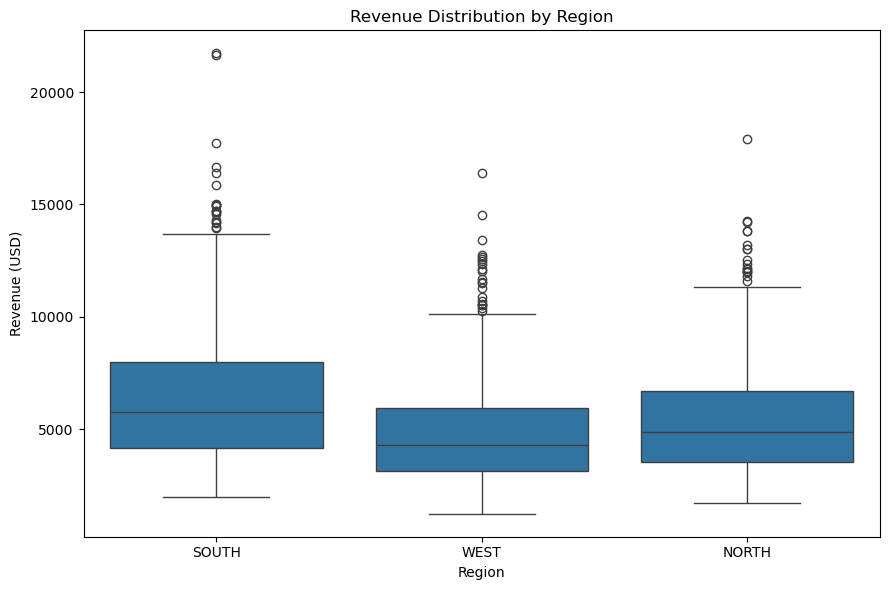


Regional IQRs:
 region
SOUTH    3854.825
NORTH    3157.880
WEST     2828.205
Name: IQR, dtype: float64
Widest IQR: SOUTH. Plain English: daily revenue varies more within this region than within the other regions.


In [21]:
# Q13 - Box plot by region

print_title(13, "Draw a box plot of revenue by region.")
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="region", y="revenue")
plt.title("Revenue Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "q13_revenue_boxplot_by_region.png", dpi=160)
plt.show()

region_iqr = df.groupby("region")["revenue"].quantile([0.25, 0.75]).unstack()
region_iqr["IQR"] = region_iqr[0.75] - region_iqr[0.25]
print("\nRegional IQRs:\n", region_iqr["IQR"].sort_values(ascending=False))
widest_region = region_iqr["IQR"].idxmax()
print(
    f"Widest IQR: {widest_region}. Plain English: daily revenue varies more "
    f"within this region than within the other regions."
)



In [22]:
# Q14 - Consistently high store

print_title(14, "Explain why a consistently high-revenue store may not be an outlier.")
store_summary = df.groupby("store_id")["revenue"].agg(["median", "mean", "max", "count"])
print(store_summary.sort_values("median", ascending=False).head())
print(
    "Interpretation: The IQR rule measures unusual observations relative to the "
    "distribution, not whether a whole store's normal level is higher. A consistently "
    "high store can therefore be a real segment/store-level difference rather than an outlier."
)




Q14. Explain why a consistently high-revenue store may not be an outlier.
            median         mean       max  count
store_id                                        
ST-12     7997.080  8521.617045  15876.48     88
ST-07     6560.585  7800.394651  21721.54     86
ST-09     6521.050  7170.798202  17732.00     89
ST-03     6436.555  6720.451333  14250.38     90
ST-11     5820.110  6559.786706  14158.45     85
Interpretation: The IQR rule measures unusual observations relative to the distribution, not whether a whole store's normal level is higher. A consistently high store can therefore be a real segment/store-level difference rather than an outlier.


In [23]:
# Q15 - Recompute footfall fences after sensor-fault removal

print_title(15, "Recompute footfall fences after removing sensor-fault days.")
sensor_mask = footfall >= 40000
clean_footfall = footfall.loc[~sensor_mask].dropna()
cfq1, cfq3 = clean_footfall.quantile([0.25, 0.75])
cfiqr = cfq3 - cfq1
clow = cfq1 - 1.5 * cfiqr
chigh = cfq3 + 1.5 * cfiqr
print(f"Before: lower={flow:.2f}, upper={fhigh:.2f}")
print(f"After : lower={clow:.2f}, upper={chigh:.2f}")
print(f"Lower shift={clow-flow:.2f}; Upper shift={chigh-fhigh:.2f}")
print(
    "Interpretation: A small number of extreme observations can materially change "
    "distribution-based fences, demonstrating sensitivity to extreme points."
)




Q15. Recompute footfall fences after removing sensor-fault days.
Before: lower=189.00, upper=1007.00
After : lower=188.12, upper=1007.12
Lower shift=-0.88; Upper shift=0.12
Interpretation: A small number of extreme observations can materially change distribution-based fences, demonstrating sensitivity to extreme points.


In [24]:
# Q16 - Revenue outlier recommendation

print_title(16, "Recommend how Meridian should treat flagged revenue outliers.")
outlier_count = len(revenue_outliers)
print(
    f"Recommendation: Do not silently drop the {outlier_count} revenue outlier rows from "
    "the board analysis. Report them separately and investigate the underlying store/day "
    "before deciding whether any are data errors. The IQR fences are "
    f"${lower_fence:,.2f} and ${upper_fence:,.2f}, so the flagged observations are "
    "statistically unusual, but unusual does not automatically mean incorrect. Keeping "
    "the main median alongside the mean also prevents a few extreme days from dominating "
    "the headline."
)




Q16. Recommend how Meridian should treat flagged revenue outliers.
Recommendation: Do not silently drop the 68 revenue outlier rows from the board analysis. Report them separately and investigate the underlying store/day before deciding whether any are data errors. The IQR fences are $-1,399.54 and $11,899.30, so the flagged observations are statistically unusual, but unusual does not automatically mean incorrect. Keeping the main median alongside the mean also prevents a few extreme days from dominating the headline.


In [25]:
# Q17 - Mean, median, mode

print_title(17, "Compute mean, median, mode and infer skew direction.")
mean_revenue = revenue.mean()
median_revenue = revenue.median()
modes = revenue.mode()
print(f"Mean={mean_revenue:.2f}")
print(f"Median={median_revenue:.2f}")
print("Mode(s):", modes.to_list())
print(
    "Interpretation: If mean > median > mode, that ordering is consistent with "
    "right-skew; if the ordering differs, use the histogram and skew coefficient too."
)




Q17. Compute mean, median, mode and infer skew direction.
Mean=5613.18
Median=4914.94
Mode(s): [3258.0, 4175.45, 4287.0, 5344.68]
Interpretation: If mean > median > mode, that ordering is consistent with right-skew; if the ordering differs, use the histogram and skew coefficient too.


In [26]:
# Q18 - Skewness
 
print_title(18, "Compute revenue skewness.")
revenue_skew = skew(revenue, bias=False)
strength = (
    "approximately symmetric" if abs(revenue_skew) < 0.5
    else "mild/moderate right-skew" if revenue_skew > 0
    else "mild/moderate left-skew"
)
if abs(revenue_skew) >= 1:
    strength = "strong right-skew" if revenue_skew > 0 else "strong left-skew"
print(f"Skewness coefficient={revenue_skew:.4f}")
print(f"Classification: {strength}")
print("Interpretation: The sign indicates the longer tail; magnitude indicates how pronounced the asymmetry is.")

 


Q18. Compute revenue skewness.
Skewness coefficient=1.3834
Classification: strong right-skew
Interpretation: The sign indicates the longer tail; magnitude indicates how pronounced the asymmetry is.



Q19. Plot revenue histogram with mean and median.


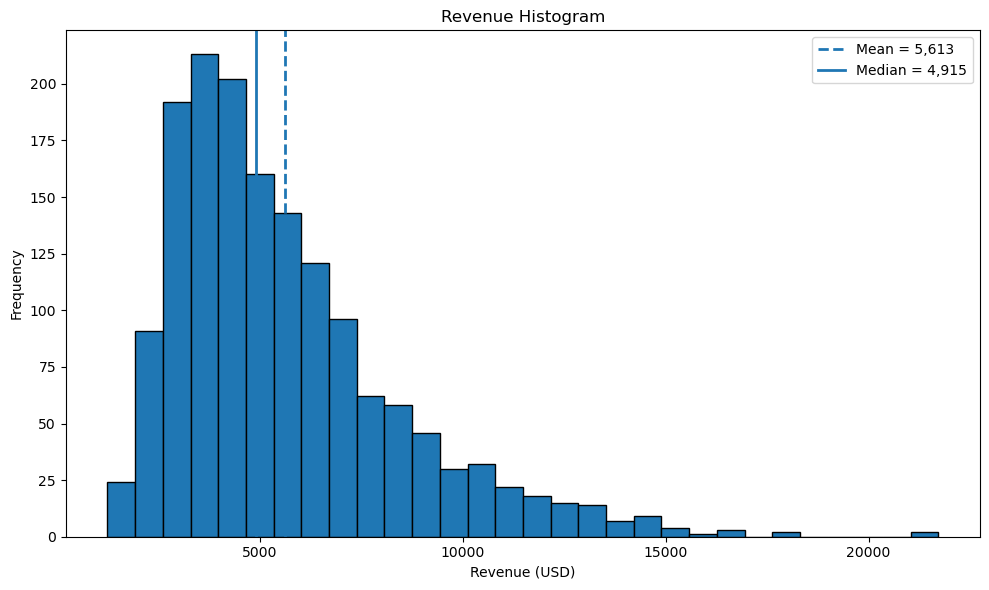

Interpretation: The histogram should visually confirm whether the longer tail is on the right or left.


In [27]:
# Q19 - Histogram
 
print_title(19, "Plot revenue histogram with mean and median.")
plt.figure(figsize=(10, 6))
plt.hist(revenue, bins=30, edgecolor="black")
plt.axvline(mean_revenue, linestyle="--", linewidth=2, label=f"Mean = {mean_revenue:,.0f}")
plt.axvline(median_revenue, linestyle="-", linewidth=2, label=f"Median = {median_revenue:,.0f}")
plt.title("Revenue Histogram")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "q19_revenue_histogram.png", dpi=160)
plt.show()
print("Interpretation: The histogram should visually confirm whether the longer tail is on the right or left.")

 

In [28]:
# Q20 - Mean vs median for board
 
print_title(20, "Choose a fairer single number for reporting.")
fairer = "median" if revenue_skew > 0 else "mean"
print(
    f"Suggested single-number headline: {fairer}. With skewness={revenue_skew:.4f}, "
    f"the {'high' if revenue_skew > 0 else 'low'} tail can pull the mean away from a typical day. "
    "The mean can still be shown as a secondary measure."
)

 


Q20. Choose a fairer single number for reporting.
Suggested single-number headline: median. With skewness=1.3834, the high tail can pull the mean away from a typical day. The mean can still be shown as a secondary measure.


In [29]:
# Q21 - Footfall skew before/after
 
print_title(21, "Compute footfall skewness before and after sensor-fault removal.")
foot_skew_before = skew(footfall.dropna(), bias=False)
foot_skew_after = skew(clean_footfall, bias=False)
print(f"Before={foot_skew_before:.4f}")
print(f"After ={foot_skew_after:.4f}")
print(f"Change={foot_skew_after-foot_skew_before:.4f}")
print("Interpretation: Removing extreme sensor values shows how much those faults were driving asymmetry.")

 


Q21. Compute footfall skewness before and after sensor-fault removal.
Before=22.9566
After =38.8177
Change=15.8611
Interpretation: Removing extreme sensor values shows how much those faults were driving asymmetry.


In [30]:
# Q22 - Plain-English right skew
 
print_title(22, "Explain right-skewed revenue to a non-technical manager.")
print(
    f"Plain English: most daily revenue observations cluster toward the lower/typical range, "
    f"while a smaller number of unusually large days stretch the distribution to the right. "
    f"For example, the overall median is ${median_revenue:,.2f} while the mean is "
    f"${mean_revenue:,.2f}; the higher mean is evidence that unusually large days are pulling "
    "the average upward. This means the average can make a typical store-day look richer than "
    "what a typical day actually produces."
)

 


Q22. Explain right-skewed revenue to a non-technical manager.
Plain English: most daily revenue observations cluster toward the lower/typical range, while a smaller number of unusually large days stretch the distribution to the right. For example, the overall median is $4,914.94 while the mean is $5,613.18; the higher mean is evidence that unusually large days are pulling the average upward. This means the average can make a typical store-day look richer than what a typical day actually produces.


In [31]:
# Q23 - Region synthesis table
 
print_title(23, "Region: median revenue, IQR, and outlier count.")
def region_stats(group):
    s = group["revenue"].dropna()
    rq1, rq3 = s.quantile([0.25, 0.75])
    rf = rq3 - rq1
    lo, hi = rq1 - 1.5 * rf, rq3 + 1.5 * rf
    return pd.Series({
        "median_revenue": s.median(),
        "IQR": rf,
        "outlier_count": int(((s < lo) | (s > hi)).sum())
    })

regional = df.groupby("region", dropna=False).apply(region_stats)
print(regional.to_string())
print("Interpretation: The table separates each region's typical revenue from its spread and unusual-value count.")

 


Q23. Region: median revenue, IQR, and outlier count.
        median_revenue       IQR  outlier_count
region                                         
NORTH          4861.09  3157.880           17.0
SOUTH          5759.32  3854.825           19.0
WEST           4287.35  2828.205           21.0
Interpretation: The table separates each region's typical revenue from its spread and unusual-value count.


C:\Users\snehp.CDACMUMBAI\AppData\Local\Temp\ipykernel_10468\389392892.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regional = df.groupby("region", dropna=False).apply(region_stats)


In [32]:
# Q24 - Investigation priority
 
print_title(24, "Identify the region Finance should investigate first.")
investigation_table = regional.sort_values(
    ["outlier_count", "IQR"], ascending=[False, False]
)
first_region = investigation_table.index[0]
first_stats = investigation_table.iloc[0]
print(
    f"Investigation focus based on the requested metrics: {first_region}. "
    f"It has median revenue ${first_stats['median_revenue']:,.2f}, IQR "
    f"${first_stats['IQR']:,.2f}, and {int(first_stats['outlier_count'])} regional outliers. "
    "This is a descriptive prioritization from the assignment's requested metrics, "
    "not a claim that the region has a business problem."
)

 


Q24. Identify the region Finance should investigate first.
Investigation focus based on the requested metrics: WEST. It has median revenue $4,287.35, IQR $2,828.20, and 21 regional outliers. This is a descriptive prioritization from the assignment's requested metrics, not a claim that the region has a business problem.


In [33]:
# Q25 - Executive summary
 
print_title(25, "Executive summary.")
print(
    f"Meridian's cleaned dataset contains {len(df):,} store-day rows after duplicate removal, "
    f"with revenue converted to numeric USD and invalid transaction/discount entries explicitly flagged. "
    f"Overall revenue has a median of ${median_revenue:,.2f}, an IQR of ${iqr:,.2f}, and "
    f"{len(revenue_outliers)} observations beyond the overall 1.5×IQR fences of "
    f"${lower_fence:,.2f} and ${upper_fence:,.2f}. "
    f"Revenue skewness is {revenue_skew:.3f}, so the mean of ${mean_revenue:,.2f} should be "
    f"interpreted alongside the median rather than treated as a complete description of a typical day. "
    f"Footfall also demonstrates the impact of the approximately 40,000-visitor sensor-fault days, "
    f"which materially change the distribution's skew/fences. "
    f"For the board report, flagged revenue observations should be investigated and shown separately "
    "rather than silently deleted, while the median provides a more robust headline when the distribution is skewed."
)

print("\nDone. Cleaned CSV and plots are in the current working directory.")


Q25. Executive summary.
Meridian's cleaned dataset contains 1,620 store-day rows after duplicate removal, with revenue converted to numeric USD and invalid transaction/discount entries explicitly flagged. Overall revenue has a median of $4,914.94, an IQR of $3,324.71, and 68 observations beyond the overall 1.5×IQR fences of $-1,399.54 and $11,899.30. Revenue skewness is 1.383, so the mean of $5,613.18 should be interpreted alongside the median rather than treated as a complete description of a typical day. Footfall also demonstrates the impact of the approximately 40,000-visitor sensor-fault days, which materially change the distribution's skew/fences. For the board report, flagged revenue observations should be investigated and shown separately rather than silently deleted, while the median provides a more robust headline when the distribution is skewed.

Done. Cleaned CSV and plots are in the current working directory.
